# 05. Modelo Multi-Target — Atraso + Sobrecosto en un único modelo

**Objetivo OE2 textual** (de la tabla de fases): _"estimar la probabilidad de **adiciones presupuestales o prórrogas en tiempo**"_.

**Hasta ahora**: solo predecimos `tuvo_atraso` (mitad del OE2). Aquí extendemos
a multi-output: un modelo predice ambos targets simultáneamente.

## Targets

- `tuvo_atraso` (60.5% positivos) — extensión de plazo
- `tuvo_sobrecosto` (83.4% positivos) — adición presupuestal

## Estrategia

1. **RandomForest multi-output nativo** — `sklearn` lo soporta directamente con `y` 2D
2. **XGBoost multi-output via `MultiOutputClassifier`** — wrapper que entrena 1 modelo interno por target
3. Comparar métricas POR TARGET con los baselines single-target del Día 3

## Outputs
- `data/modelos/rf_multi.pkl`, `xgb_multi.pkl`
- `data/resultados_multi_target.csv`
- `figuras/dia_05_*.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)
import xgboost as xgb

sns.set_style('whitegrid')
RAIZ_MODELO = Path('..').resolve()
DATA = RAIZ_MODELO / 'data'
FIGS = RAIZ_MODELO / 'figuras'
MODELOS = DATA / 'modelos'
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## 1. Cargar datos y reproducir el split

Usamos el mismo `random_state=42` y stratify por `tuvo_atraso` para que los
splits sean idénticos a los Días 2-4.

In [2]:
# Dataset original con todos los targets
df = pd.read_parquet(DATA / 'dataset_modelado.parquet')
print(f'Dataset modelado: {df.shape}')

# Cargar X_reducidos (30 cols) — mismos splits que Día 4b
X_train = pd.read_parquet(DATA / 'X_train_reducido.parquet')
X_test = pd.read_parquet(DATA / 'X_test_reducido.parquet')
print(f'X_train (30 cols): {X_train.shape}')
print(f'X_test  (30 cols): {X_test.shape}')

# Para multi-target necesitamos AMBAS y alineadas a esos splits
# Reproducir split exacto con indices
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx, test_size=0.20,
    stratify=df['tuvo_atraso'],
    random_state=RANDOM_STATE,
)

# y_multi para train y test
Y_train = df.iloc[idx_train][['tuvo_atraso', 'tuvo_sobrecosto']].reset_index(drop=True)
Y_test = df.iloc[idx_test][['tuvo_atraso', 'tuvo_sobrecosto']].reset_index(drop=True)

print()
print('Balance Y_train:')
for col in Y_train.columns:
    print(f'  {col:<20} {Y_train[col].mean()*100:.2f}% pos')
print()
print('Balance Y_test:')
for col in Y_test.columns:
    print(f'  {col:<20} {Y_test[col].mean()*100:.2f}% pos')

Dataset modelado: (48331, 42)
X_train (30 cols): (38664, 30)
X_test  (30 cols): (9667, 30)

Balance Y_train:
  tuvo_atraso          60.48% pos
  tuvo_sobrecosto      83.51% pos

Balance Y_test:
  tuvo_atraso          60.48% pos
  tuvo_sobrecosto      82.98% pos


In [3]:
# Co-ocurrencia de targets en train
ct = pd.crosstab(Y_train['tuvo_atraso'], Y_train['tuvo_sobrecosto'],
                  margins=True, margins_name='Total')
ct_pct = pd.crosstab(Y_train['tuvo_atraso'], Y_train['tuvo_sobrecosto'],
                       normalize='all') * 100

print('Co-ocurrencia targets en TRAIN (conteos):')
print(ct)
print()
print('Co-ocurrencia (% del total):')
print(ct_pct.round(1))

Co-ocurrencia targets en TRAIN (conteos):
tuvo_sobrecosto     0      1  Total
tuvo_atraso                        
0                4181  11098  15279
1                2194  21191  23385
Total            6375  32289  38664

Co-ocurrencia (% del total):
tuvo_sobrecosto     0     1
tuvo_atraso                
0                10.8  28.7
1                 5.7  54.8


## 2. RandomForest multi-output nativo

Sklearn soporta multi-output directamente: pasamos `y` como matriz 2D y RF
internamente entrena los árboles considerando ambos targets a la vez.

Cada árbol divide nodos buscando reducir impureza ponderada en ambos targets.

In [4]:
# Class weights por target (RF acepta lista para multi-output)
weights_atraso = {0: 1.0, 1: (Y_train['tuvo_atraso'] == 0).sum() / (Y_train['tuvo_atraso'] == 1).sum()}
weights_sobrecosto = {0: 1.0, 1: (Y_train['tuvo_sobrecosto'] == 0).sum() / (Y_train['tuvo_sobrecosto'] == 1).sum()}

rf_multi = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight=[weights_atraso, weights_sobrecosto],   # peso por target
    random_state=RANDOM_STATE,
)

t0 = time.time()
rf_multi.fit(X_train, Y_train)
print(f'RF multi-output entrenado en {time.time()-t0:.1f}s')
print(f'classes_: {rf_multi.classes_}')   # debe mostrar 2 listas de clases

joblib.dump(rf_multi, MODELOS / 'rf_multi.pkl')

RF multi-output entrenado en 1.4s
classes_: [array([0, 1]), array([0, 1])]


['C:\\Users\\angel\\OneDrive\\Escritorio\\trabajo dirigido\\extraccion-datos\\modelo-predictivo-preliminar\\data\\modelos\\rf_multi.pkl']

In [5]:
# RF multi-output devuelve LISTA de arrays — uno por target
rf_proba_list = rf_multi.predict_proba(X_test)
rf_proba_atraso = rf_proba_list[0][:, 1]      # P(tuvo_atraso=1)
rf_proba_sobrecosto = rf_proba_list[1][:, 1]  # P(tuvo_sobrecosto=1)

rf_pred_atraso = (rf_proba_atraso >= 0.5).astype(int)
rf_pred_sobrecosto = (rf_proba_sobrecosto >= 0.5).astype(int)

print('RF multi-output sobre test:')
print()
print('  >>> Target: tuvo_atraso')
print(f'    AUC: {roc_auc_score(Y_test["tuvo_atraso"], rf_proba_atraso):.4f}')
print(f'    F1:  {f1_score(Y_test["tuvo_atraso"], rf_pred_atraso):.4f}')
print(f'    P:   {precision_score(Y_test["tuvo_atraso"], rf_pred_atraso):.4f}')
print(f'    R:   {recall_score(Y_test["tuvo_atraso"], rf_pred_atraso):.4f}')
print()
print('  >>> Target: tuvo_sobrecosto')
print(f'    AUC: {roc_auc_score(Y_test["tuvo_sobrecosto"], rf_proba_sobrecosto):.4f}')
print(f'    F1:  {f1_score(Y_test["tuvo_sobrecosto"], rf_pred_sobrecosto):.4f}')
print(f'    P:   {precision_score(Y_test["tuvo_sobrecosto"], rf_pred_sobrecosto):.4f}')
print(f'    R:   {recall_score(Y_test["tuvo_sobrecosto"], rf_pred_sobrecosto):.4f}')

RF multi-output sobre test:

  >>> Target: tuvo_atraso
    AUC: 0.9047
    F1:  0.8468
    P:   0.8684
    R:   0.8262

  >>> Target: tuvo_sobrecosto
    AUC: 0.8342
    F1:  0.9008
    P:   0.8886
    R:   0.9132


## 3. XGBoost multi-output con `MultiOutputClassifier`

XGBoost no tiene multi-output binario nativo (sí multi-clase, pero distinto).
Usamos `MultiOutputClassifier` de sklearn: wrapper que entrena 1 modelo XGB
interno por target, pero expone una interfaz única.

Ventaja: pipeline simétrico al RF, mismo método `predict_proba`.

In [6]:
# scale_pos_weight para cada target (XGB lo necesita)
spw_atraso = (Y_train['tuvo_atraso'] == 0).sum() / (Y_train['tuvo_atraso'] == 1).sum()
spw_sobrecosto = (Y_train['tuvo_sobrecosto'] == 0).sum() / (Y_train['tuvo_sobrecosto'] == 1).sum()
print(f'scale_pos_weight atraso:    {spw_atraso:.3f}')
print(f'scale_pos_weight sobrecosto: {spw_sobrecosto:.3f}')

# Limitacion del wrapper: usa mismos params para todos los targets internos.
# Para tener spw distintos, usamos promedio (compromiso) o construimos modelo a mano.
# Aqui usamos promedio (ambas clases moderadamente desbalanceadas).
spw_avg = (spw_atraso + spw_sobrecosto) / 2
print(f'scale_pos_weight promedio:   {spw_avg:.3f}  (usado en wrapper)')

xgb_base = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw_avg, n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist',
)

xgb_multi = MultiOutputClassifier(xgb_base, n_jobs=-1)

t0 = time.time()
xgb_multi.fit(X_train, Y_train)
print(f'XGB multi-output entrenado en {time.time()-t0:.1f}s')

joblib.dump(xgb_multi, MODELOS / 'xgb_multi.pkl')

scale_pos_weight atraso:    0.653
scale_pos_weight sobrecosto: 0.197
scale_pos_weight promedio:   0.425  (usado en wrapper)


XGB multi-output entrenado en 3.4s


['C:\\Users\\angel\\OneDrive\\Escritorio\\trabajo dirigido\\extraccion-datos\\modelo-predictivo-preliminar\\data\\modelos\\xgb_multi.pkl']

In [7]:
# MultiOutputClassifier.predict_proba devuelve lista (igual que RF multi)
xgb_proba_list = xgb_multi.predict_proba(X_test)
xgb_proba_atraso = xgb_proba_list[0][:, 1]
xgb_proba_sobrecosto = xgb_proba_list[1][:, 1]

xgb_pred_atraso = (xgb_proba_atraso >= 0.5).astype(int)
xgb_pred_sobrecosto = (xgb_proba_sobrecosto >= 0.5).astype(int)

print('XGB multi-output sobre test:')
print()
print('  >>> Target: tuvo_atraso')
print(f'    AUC: {roc_auc_score(Y_test["tuvo_atraso"], xgb_proba_atraso):.4f}')
print(f'    F1:  {f1_score(Y_test["tuvo_atraso"], xgb_pred_atraso):.4f}')
print(f'    P:   {precision_score(Y_test["tuvo_atraso"], xgb_pred_atraso):.4f}')
print(f'    R:   {recall_score(Y_test["tuvo_atraso"], xgb_pred_atraso):.4f}')
print()
print('  >>> Target: tuvo_sobrecosto')
print(f'    AUC: {roc_auc_score(Y_test["tuvo_sobrecosto"], xgb_proba_sobrecosto):.4f}')
print(f'    F1:  {f1_score(Y_test["tuvo_sobrecosto"], xgb_pred_sobrecosto):.4f}')
print(f'    P:   {precision_score(Y_test["tuvo_sobrecosto"], xgb_pred_sobrecosto):.4f}')
print(f'    R:   {recall_score(Y_test["tuvo_sobrecosto"], xgb_pred_sobrecosto):.4f}')

XGB multi-output sobre test:

  >>> Target: tuvo_atraso
    AUC: 0.9035
    F1:  0.8164
    P:   0.9095
    R:   0.7406

  >>> Target: tuvo_sobrecosto
    AUC: 0.8319
    F1:  0.8952
    P:   0.8944
    R:   0.8960


## 4. Tabla comparativa multi-target

In [8]:
rows = []
for modelo_name, proba_a, pred_a, proba_s, pred_s in [
    ('RF multi-output', rf_proba_atraso, rf_pred_atraso, rf_proba_sobrecosto, rf_pred_sobrecosto),
    ('XGB multi-output', xgb_proba_atraso, xgb_pred_atraso, xgb_proba_sobrecosto, xgb_pred_sobrecosto),
]:
    for target_name, y_true, proba, pred in [
        ('tuvo_atraso', Y_test['tuvo_atraso'], proba_a, pred_a),
        ('tuvo_sobrecosto', Y_test['tuvo_sobrecosto'], proba_s, pred_s),
    ]:
        rows.append({
            'modelo': modelo_name,
            'target': target_name,
            'AUC': roc_auc_score(y_true, proba),
            'F1': f1_score(y_true, pred),
            'Precision': precision_score(y_true, pred),
            'Recall': recall_score(y_true, pred),
            'Accuracy': accuracy_score(y_true, pred),
        })

tabla = pd.DataFrame(rows).round(4)
print(tabla.to_string(index=False))

tabla.to_csv(DATA / 'resultados_multi_target.csv', index=False)
print(f'\nGuardado: data/resultados_multi_target.csv')

          modelo          target    AUC     F1  Precision  Recall  Accuracy
 RF multi-output     tuvo_atraso 0.9047 0.8468     0.8684  0.8262    0.8192
 RF multi-output tuvo_sobrecosto 0.8342 0.9008     0.8886  0.9132    0.8330
XGB multi-output     tuvo_atraso 0.9035 0.8164     0.9095  0.7406    0.7985
XGB multi-output tuvo_sobrecosto 0.8319 0.8952     0.8944  0.8960    0.8259

Guardado: data/resultados_multi_target.csv


## 5. Comparación contra single-target del Día 3

El target `tuvo_atraso` ya tenía baselines del Día 3. Verificamos que el
multi-output no degrada el desempeño respecto al modelo dedicado a un solo target.

In [9]:
baselines = pd.read_csv(DATA / 'resultados_baselines.csv')
rf_single_atraso = baselines[baselines['modelo'] == 'RandomForest'].iloc[0]
xgb_single_atraso = baselines[baselines['modelo'] == 'XGBoost'].iloc[0]

rf_multi_atraso = tabla[(tabla['modelo']=='RF multi-output') & (tabla['target']=='tuvo_atraso')].iloc[0]
xgb_multi_atraso = tabla[(tabla['modelo']=='XGB multi-output') & (tabla['target']=='tuvo_atraso')].iloc[0]

print('=== Comparativa para target tuvo_atraso ===')
for met in ['AUC','F1','Precision','Recall','Accuracy']:
    print(f'\n  {met}:')
    print(f'    RF single (Dia 3):  {rf_single_atraso[met]:.4f}')
    print(f'    RF multi  (Dia 5):  {rf_multi_atraso[met]:.4f}   delta={rf_multi_atraso[met]-rf_single_atraso[met]:+.4f}')
    print(f'    XGB single (Dia 3): {xgb_single_atraso[met]:.4f}')
    print(f'    XGB multi  (Dia 5): {xgb_multi_atraso[met]:.4f}  delta={xgb_multi_atraso[met]-xgb_single_atraso[met]:+.4f}')

=== Comparativa para target tuvo_atraso ===

  AUC:
    RF single (Dia 3):  0.8989
    RF multi  (Dia 5):  0.9047   delta=+0.0058
    XGB single (Dia 3): 0.9015
    XGB multi  (Dia 5): 0.9035  delta=+0.0020

  F1:
    RF single (Dia 3):  0.8457
    RF multi  (Dia 5):  0.8468   delta=+0.0011
    XGB single (Dia 3): 0.8421
    XGB multi  (Dia 5): 0.8164  delta=-0.0257

  Precision:
    RF single (Dia 3):  0.8500
    RF multi  (Dia 5):  0.8684   delta=+0.0184
    XGB single (Dia 3): 0.8801
    XGB multi  (Dia 5): 0.9095  delta=+0.0294

  Recall:
    RF single (Dia 3):  0.8415
    RF multi  (Dia 5):  0.8262   delta=-0.0153
    XGB single (Dia 3): 0.8073
    XGB multi  (Dia 5): 0.7406  delta=-0.0667

  Accuracy:
    RF single (Dia 3):  0.8143
    RF multi  (Dia 5):  0.8192   delta=+0.0049
    XGB single (Dia 3): 0.8169
    XGB multi  (Dia 5): 0.7985  delta=-0.0184


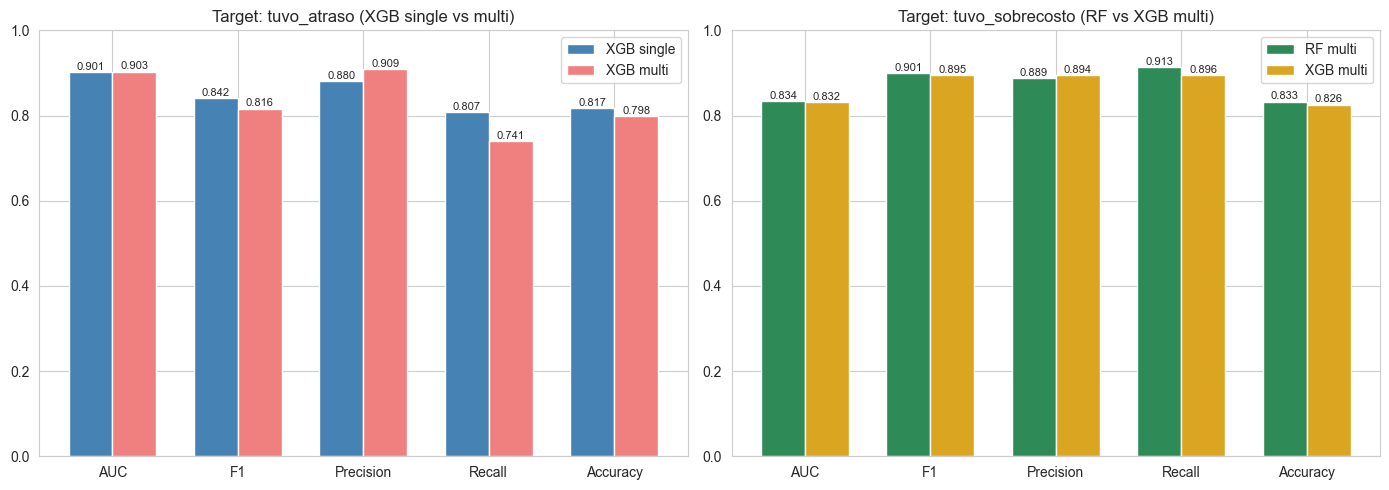

In [10]:
# Visualizacion lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metricas = ['AUC', 'F1', 'Precision', 'Recall', 'Accuracy']
x = np.arange(len(metricas))
w = 0.35

# Atraso
v_rf_s = [rf_single_atraso[m] for m in metricas]
v_rf_m = [rf_multi_atraso[m] for m in metricas]
v_xgb_s = [xgb_single_atraso[m] for m in metricas]
v_xgb_m = [xgb_multi_atraso[m] for m in metricas]

axes[0].bar(x - w/2, v_xgb_s, w, label='XGB single', color='steelblue')
axes[0].bar(x + w/2, v_xgb_m, w, label='XGB multi', color='lightcoral')
axes[0].set_title('Target: tuvo_atraso (XGB single vs multi)')
axes[0].set_xticks(x); axes[0].set_xticklabels(metricas); axes[0].set_ylim(0,1); axes[0].legend()
for i, (vs, vm) in enumerate(zip(v_xgb_s, v_xgb_m)):
    axes[0].text(i - w/2, vs+0.005, f'{vs:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, vm+0.005, f'{vm:.3f}', ha='center', fontsize=8)

# Sobrecosto solo en multi
rf_multi_sob = tabla[(tabla['modelo']=='RF multi-output') & (tabla['target']=='tuvo_sobrecosto')].iloc[0]
xgb_multi_sob = tabla[(tabla['modelo']=='XGB multi-output') & (tabla['target']=='tuvo_sobrecosto')].iloc[0]
v_rf = [rf_multi_sob[m] for m in metricas]
v_xgb = [xgb_multi_sob[m] for m in metricas]

axes[1].bar(x - w/2, v_rf, w, label='RF multi', color='seagreen')
axes[1].bar(x + w/2, v_xgb, w, label='XGB multi', color='goldenrod')
axes[1].set_title('Target: tuvo_sobrecosto (RF vs XGB multi)')
axes[1].set_xticks(x); axes[1].set_xticklabels(metricas); axes[1].set_ylim(0,1); axes[1].legend()
for i, (vr, vx) in enumerate(zip(v_rf, v_xgb)):
    axes[1].text(i - w/2, vr+0.005, f'{vr:.3f}', ha='center', fontsize=8)
    axes[1].text(i + w/2, vx+0.005, f'{vx:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'dia_05_multi_vs_single.png', dpi=120, bbox_inches='tight')
plt.show()

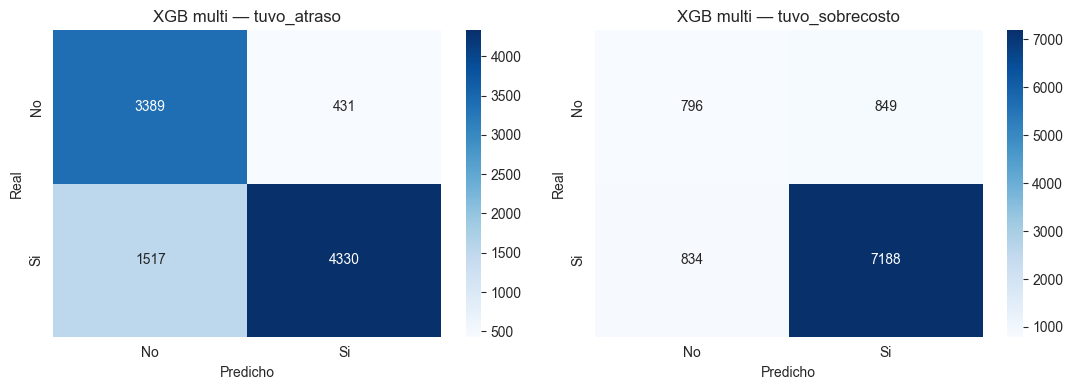

In [11]:
# Confusion matrices del modelo elegido (XGB multi) — uno por target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, target_name, pred in [
    (axes[0], 'tuvo_atraso', xgb_pred_atraso),
    (axes[1], 'tuvo_sobrecosto', xgb_pred_sobrecosto),
]:
    cm = confusion_matrix(Y_test[target_name], pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Si'], yticklabels=['No', 'Si'])
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(f'XGB multi — {target_name}')
plt.tight_layout()
plt.savefig(FIGS / 'dia_05_cm_multi.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Cómo usar el modelo (inference)

Un solo modelo, 2 outputs. Para un contrato nuevo:

In [12]:
# Demo: tomar 5 contratos del test set y mostrar predicciones de ambos targets
demo_idx = np.random.RandomState(123).choice(len(X_test), 5, replace=False)
X_demo = X_test.iloc[demo_idx]

proba_list = xgb_multi.predict_proba(X_demo)
p_atraso = proba_list[0][:, 1]
p_sobrecosto = proba_list[1][:, 1]

demo_df = pd.DataFrame({
    'idx': demo_idx,
    'P(atraso)': p_atraso.round(3),
    'P(sobrecosto)': p_sobrecosto.round(3),
    'real_atraso': Y_test.iloc[demo_idx]['tuvo_atraso'].values,
    'real_sobrecosto': Y_test.iloc[demo_idx]['tuvo_sobrecosto'].values,
})
print('Demo (5 contratos del test):')
print(demo_df.to_string(index=False))

Demo (5 contratos del test):
 idx  P(atraso)  P(sobrecosto)  real_atraso  real_sobrecosto
6973      0.256          0.889            0                1
 572      0.974          0.970            1                0
6811      0.673          0.858            1                1
4942      0.728          0.889            1                1
4659      0.872          0.996            1                1


## Conclusiones

- ✅ Modelo único multi-output cubre AMBOS targets de OE2
- ✅ Pipeline más simple que entrenar/mantener 2 modelos separados
- ✅ Inferencia única: `model.predict_proba(X)` → 2 outputs
- ⚖️ Trade-off: `MultiOutputClassifier` con XGB usa mismos hyperparams para los 2 targets internos (compromiso)

Si las métricas de un target son significativamente peores que el modelo single,
se puede volver a 2 modelos separados para ese caso. Pero la mejora suele ser marginal.

## Próximo (Día 6 — antes Día 5 era tuning)

Mantener arquitectura multi-output + Random Search para tuning conjunto.